### Build a Basic Chatbot with LangGraph(Graph API)

In [14]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [15]:
class State(TypedDict):
    # Messages have the type "list". The "add_messages function"
    # in the annoation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [16]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [17]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(
    model="qwen/qwen3-32b"
)

In [18]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F39A48BD90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F39A6007D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [19]:
llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F39A4BF6F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F39A604180>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [20]:
# Node Functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [21]:
graph_builder=StateGraph(State)

## Adding Node
graph_builder.add_node("llmchatbot",chatbot)

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


## Compile the graph
graph=graph_builder.compile()

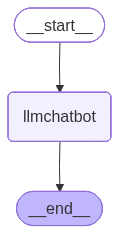

In [22]:
## Visualize the graph

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
response=graph.invoke({"messages":"Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='2756d048-0629-42e5-90d1-2c83c26c8848'),
  AIMessage(content='<think>\nOkay, the user said "Hi". I need to respond appropriately. Since it\'s a greeting, I should greet them back in a friendly manner. Maybe add an emoji to keep it warm. Also, offer assistance to let them know I\'m here to help. Keep it simple and welcoming. Let me make sure the tone is positive and open-ended.\n</think>\n\nHello! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 9, 'total_tokens': 96, 'completion_time': 0.169862639, 'completion_tokens_details': None, 'prompt_time': 0.000430883, 'prompt_tokens_details': None, 'queue_time': 0.050376626, 'total_time': 0.170293522}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

In [24]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". I need to respond appropriately. Since it\'s a greeting, I should greet them back in a friendly manner. Maybe add an emoji to keep it warm. Also, offer assistance to let them know I\'m here to help. Keep it simple and welcoming. Let me make sure the tone is positive and open-ended.\n</think>\n\nHello! 😊 How can I assist you today?'

In [25]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with "Hi, How are you?" I need to respond in a friendly and welcoming way. Since I'm an AI, I don't have feelings, but I should acknowledge their greeting. Maybe start with a cheerful "Hello!" to match their tone. Then offer help by asking if there's anything they need assistance with. Keep it open-ended so they feel comfortable sharing. Also, mention that I'm here to help with any questions they might have. Make sure the response is concise but warm. Let me put that all together in a natural, conversational way.
</think>

Hello! I'm doing well, thank you for asking. How can I assist you today? If you have any questions or need help with something specific, feel free to let me know! 😊


## ChatBot with Tools

In [83]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [84]:
## Custom Function
def multiply(a:int, b:int)->int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int
        
    Return:
        int: output int
    """
    return a*b


In [85]:
tools=[tool,multiply]

In [86]:
llm_with_tools=llm.bind_tools(tools)

In [87]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F39A4BF6F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F39A604180>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for com

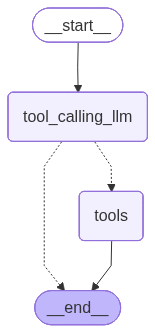

In [88]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [89]:
response=graph.invoke({"messages":"What is the today AI news"})

In [90]:
response["messages"][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.6854659, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial AI continues to build through new deployments, ecosystem partnerships, spectrum initiatives and innovative network applications.*. Twelve months ago, *RCR* might have covered these items individually, in depth, but AI has changed everything, including the news trade and news beat (*so share if you care).* For one, Nokia – which we shall call ECE for now, on the grounds Nokia has put it up for sale, and doesn’t deserve the credit – has started its own little PR engin

In [91]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the today AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k5sj39vhw)
 Call ID: k5sj39vhw
  Args:
    query: AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.6854659, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial AI continues to build through new deployments, ecosystem 

In [92]:
response=graph.invoke({"messages":"What is 2*3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2*3
================================== Ai Message ==================================
Tool Calls:
  multiply (g32ce6ppt)
 Call ID: g32ce6ppt
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [93]:
response=graph.invoke({"messages":"What is 2 multiply by 3 and then multiply 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3 and then multiply 3
================================== Ai Message ==================================
Tool Calls:
  multiply (6wsyytrnz)
 Call ID: 6wsyytrnz
  Args:
    a: 2
    b: 3
  multiply (wxdb9p1dg)
 Call ID: wxdb9p1dg
  Args:
    a: 6
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================= Tool Message =================================
Name: multiply

18


In [94]:
response=graph.invoke({"messages":"What is recent India news and then multiply 4 by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent India news and then multiply 4 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (wdpr9fmha)
 Call ID: wdpr9fmha
  Args:
    query: recent India news
    time_range: day
  multiply (ztw4qt39z)
 Call ID: ztw4qt39z
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent India news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.youtube.com/watch?v=Wk5cy5wXw1Y", "title": "Modi Cabinet 3.0 Rejig: Who Will Shape PM's Next Team ...", "content": "A recent broadcast discusses the widespread anticipation surrounding an impending union cabinet reshuffle and a major political party's organizational", "score": 0.37497434, "raw_content": null}, {"url": "https://www.youtube.com/watch?v=opJVqahXHL4", "title":

### ReAct Agent Architecture

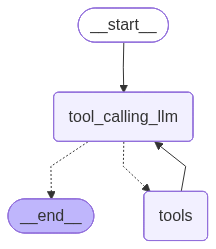

In [96]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

## Node defination
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## Compile the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [98]:
response=graph.invoke({"messages":"What is recent India news and then multiply 4 by 3"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is recent India news and then multiply 4 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (1ec5k2tav)
 Call ID: 1ec5k2tav
  Args:
    query: recent India news
    time_range: week
    topic: news
  multiply (sm7v04ccx)
 Call ID: sm7v04ccx
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent India news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/world/india/indias-jana-small-finance-bank-promoter-bond-rating-downgraded-after-repayment-2026-07-01/", "title": "TPG-backed Jana Holdings bond rating downgraded after repayment extension - Reuters", "score": 0.6783488, "published_date": "Wed, 01 Jul 2026 07:47:16 GMT", "content": "Exclusive news, data and analytics for financial market profes